In [1]:
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.SeqIO as SeqIO

In [2]:
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
len(WT_DNA)

822

In [3]:
records = []
with gzip.open("./data/bc1036-no-indel.fa.gz", "rt") as handle:
    records = list(SeqIO.parse(handle, "fasta")) 

df = pd.DataFrame([{'id':r.id, 'seq':str(r.seq)} for r in records])

In [4]:
id_split = df.id.str.split("/", expand=True)
id_split.columns = ["batch_id", "seqid", "ccs", "direction"]
del id_split["batch_id"] # there should be only one
del id_split["ccs"] # this is ccs everywhere
id_split.head()

,seqid,direction
0,194,fwd
1,194,rev
2,279,fwd
3,279,rev
4,428,fwd


In [5]:
def hamming_dist(str1, str2=WT_DNA):
    if len(str1) != len(str2):
        raise ValueError("Strings have different lengths")
    return sum(s1 != s2 for s1, s2 in zip(str1, str2))

In [6]:
def pp_diff(str1, str2=WT_DNA):
    if len(str1) != len(str2):
        raise ValueError("Strings have different lengths")
    for i, (s1, s2) in enumerate(zip(str1, str2)):
        if s1 != s2:
            print(f"At {i:03d} : nt1= {s1}, nt2 = {s2} ")

In [7]:
df["seqid"] = id_split["seqid"]
df["direction"] = id_split["direction"]
df["length"] = df.seq.str.len()
del df["id"]
df.head()

,seq,seqid,direction,length
0,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,194,fwd,822
1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,194,rev,822
2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,279,fwd,822
3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,279,rev,822
4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,428,fwd,822


In [8]:
df_filter = df[df.length == len(WT_DNA)].copy()
len(df_filter)  / len(df)

0.9885624885180422

3

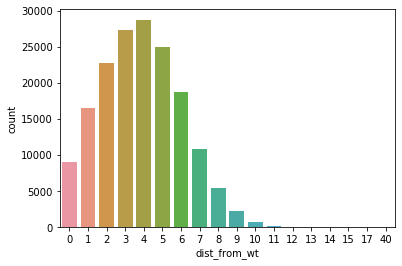

In [9]:
df_filter["dist_from_wt"] = df_filter.seq.apply(hamming_dist)

sns.countplot(x="dist_from_wt", data=df_filter)

hamming_dist(df.iloc[0].seq,df.iloc[1].seq )

In [10]:
pp_diff(df.iloc[0].seq, df.iloc[1].seq )

At 192 : nt1= G, nt2 = A 
At 209 : nt1= A, nt2 = T 
At 275 : nt1= A, nt2 = G 


In [11]:
hamming_dist(df.iloc[0].seq, WT_DNA)

1

In [12]:
pp_diff(df.iloc[0].seq, WT_DNA)

At 573 : nt1= A, nt2 = G 


In [13]:
hamming_dist(df.iloc[1].seq, WT_DNA)

4

In [14]:
pp_diff(df.iloc[1].seq, WT_DNA)

At 192 : nt1= A, nt2 = G 
At 209 : nt1= T, nt2 = A 
At 275 : nt1= G, nt2 = A 
At 573 : nt1= A, nt2 = G 
